## 9. Relações cardiometabólicas

### Objetivo

Após analisar individualmente os principais indicadores de saúde, esta seção investiga como diferentes características do perfil cardiometabólico se relacionam na amostra.

São consideradas medidas de composição corporal, controle glicêmico, pressão arterial e perfil lipídico. O objetivo é verificar se esses indicadores apresentam associações lineares entre si e compreender se fornecem informações semelhantes ou complementares sobre os participantes.

Para isso, é utilizado o coeficiente de correlação de Pearson. Os coeficientes variam de -1 a 1, indicando a direção e a intensidade da associação linear entre duas variáveis.

As relações apresentadas são descritivas. Como os dados analisados são transversais, as associações observadas não permitem estabelecer relações de causa e efeito.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Identidade visual do HealthSync
COR_PRINCIPAL = "#0E766D"
COR_SECUNDARIA = "#10B981"
COR_TERCIARIA = "#14B8A6"

COR_DESTAQUE = "#F28C82"
COR_NEUTRA = "#94A3B8"

# Cores consistentes para respostas binárias
COR_SIM = COR_PRINCIPAL
COR_NAO = COR_NEUTRA

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["figure.dpi"] = 120

In [16]:
CAMINHO_CORE = "../../dataset/healthsync_nhanes_2021_2023_core.csv"

df = pd.read_csv(CAMINHO_CORE)

print("Dataset carregado com sucesso.")
print(f"Participantes: {df.shape[0]}")
print(f"Variáveis: {df.shape[1]}")

display(df.head())

Dataset carregado com sucesso.
Participantes: 5283
Variáveis: 23


,id_participante,peso_estatistico_mec,peso_estatistico_entrevista,psu,estrato_amostral,idade,sexo,imc,pressao_sistolica,pressao_diastolica,...,glicose_jejum,colesterol_total,diabetes_informado,hipertensao_informada,hipertensao_2consultas,colesterol_alto_informado,medicamento_pressao,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
0,130378.0,54.374.463.898,50.055.450.807,2.0,173.0,43.0,Homem,27.0,132.7,96.0,...,113.0,264.0,Nao,1.0,1.0,0.0,1.0,135.0,135.0,360.0
1,130379.0,34.084.721.548,29.087.450.605,2.0,173.0,66.0,Homem,33.5,117.0,78.7,...,99.0,214.0,Nao,1.0,1.0,0.0,1.0,180.0,135.0,480.0
2,130380.0,81.196.277.992,80.062.674.301,1.0,174.0,44.0,Mulher,29.7,109.0,78.3,...,156.0,187.0,Sim,0.0,NaN,1.0,NaN,20.0,0.0,240.0
3,130386.0,3.998.845.294,3.099.528.261,1.0,179.0,34.0,Homem,30.2,115.0,73.7,...,100.0,183.0,Nao,0.0,NaN,0.0,NaN,30.0,6.9,180.0
4,130387.0,2.077.625.485,19.896.970.559,1.0,181.0,68.0,Mulher,42.6,141.3,76.0,...,NaN,203.0,Nao,1.0,1.0,1.0,1.0,0.0,0.0,1200.0


### 9.1 Matriz de correlação

**Pergunta da análise:** como os principais indicadores cardiometabólicos se relacionam linearmente entre si?

Inicialmente, é construída uma matriz de correlação envolvendo IMC, HbA1c, pressão sistólica, pressão diastólica e colesterol total.

Essa análise fornece uma visão geral das associações antes da investigação individual de algumas relações de interesse.

In [17]:
variaveis_cardio = [
    "imc",
    "hba1c",
    "pressao_sistolica",
    "pressao_diastolica",
    "colesterol_total"
]

correlacoes_cardio = (
    df[variaveis_cardio]
    .corr(method="pearson")
    .round(3)
)

display(correlacoes_cardio)

,imc,hba1c,pressao_sistolica,pressao_diastolica,colesterol_total
imc,1.000,0.197,0.017,0.195,-0.040
hba1c,0.197,1.000,0.146,0.059,-0.039
pressao_sistolica,0.017,0.146,1.000,0.612,0.052
pressao_diastolica,0.195,0.059,0.612,1.000,0.177
colesterol_total,-0.040,-0.039,0.052,0.177,1.000


**Observação inicial**

A matriz mostra diferentes níveis de associação entre os indicadores analisados. A relação mais evidente ocorre entre pressão sistólica e diastólica, com correlação de **0,612**, resultado já investigado anteriormente na análise da pressão arterial.

Entre indicadores pertencentes a diferentes dimensões do perfil cardiometabólico, os coeficientes são menores. Essas relações serão examinadas individualmente nas próximas etapas.

### 9.2 IMC × HbA1c

**Pergunta da análise:** existe associação linear entre IMC e HbA1c na amostra?

Essa relação conecta uma característica antropométrica com um indicador do perfil glicêmico. Como ambas são informações potencialmente relevantes para a caracterização cardiometabólica utilizada pelo HealthSync, é importante verificar como se relacionam na base analisada.

O coeficiente de correlação de Pearson é utilizado para avaliar a direção e a intensidade da associação linear entre as duas variáveis.

In [18]:
# ============================================================
# CORRELAÇÃO — IMC × HbA1c
# ============================================================

corr_imc_hba1c = (
    df[
        [
            "imc",
            "hba1c"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlação IMC × HbA1c: "
    f"{corr_imc_hba1c:.3f}"
)

Correlação IMC × HbA1c: 0.197


O IMC e a HbA1c apresentaram correlação de Pearson de **0,197**, indicando uma associação linear positiva na amostra.

O coeficiente mostra que valores mais elevados de IMC apresentam alguma tendência de ocorrer juntamente com valores mais elevados de HbA1c, mas a associação linear observada é limitada.

Esse resultado não permite concluir que alterações no IMC provoquem alterações na HbA1c. Além disso, a correlação avalia apenas a relação linear entre as duas variáveis e não considera simultaneamente outras características dos participantes.

### 9.3 IMC × pressão arterial

**Pergunta da análise:** existe associação linear entre IMC e as medidas de pressão arterial na amostra?

Para investigar essa relação, o IMC é comparado separadamente com a pressão sistólica e com a pressão diastólica.

Essa análise permite verificar se a associação do IMC ocorre de maneira semelhante com os dois componentes da pressão arterial.

In [19]:
corr_imc_sistolica = (
    df[
        [
            "imc",
            "pressao_sistolica"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlação IMC × pressão sistólica: "
    f"{corr_imc_sistolica:.3f}"
)

Correlação IMC × pressão sistólica: 0.017


In [20]:
corr_imc_diastolica = (
    df[
        [
            "imc",
            "pressao_diastolica"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlação IMC × pressão diastólica: "
    f"{corr_imc_diastolica:.3f}"
)

Correlação IMC × pressão diastólica: 0.195


O IMC apresentou correlação de **0,017** com a pressão sistólica e de **0,195** com a pressão diastólica.

Na amostra analisada, praticamente não foi observada associação linear entre IMC e pressão sistólica. Para a pressão diastólica, o coeficiente foi positivo e maior, embora ainda distante de representar uma relação linear elevada.

Os resultados também mostram que a relação do IMC com os dois componentes da pressão arterial não ocorre da mesma forma.

Essas associações são descritivas e não permitem concluir que diferenças no IMC sejam responsáveis pelas diferenças observadas na pressão arterial.

### 9.4 HbA1c × pressão arterial

**Pergunta da análise:** existe associação linear entre o indicador glicêmico e as medidas de pressão arterial?

A HbA1c é comparada com a pressão sistólica e a pressão diastólica para investigar se o perfil glicêmico apresenta associação linear com essas medidas na amostra.

A análise é exploratória e busca compreender como diferentes dimensões do perfil cardiometabólico se relacionam antes da etapa de Machine Learning.

In [21]:
corr_hba1c_pressao = (
    df[
        [
            "hba1c",
            "pressao_sistolica",
            "pressao_diastolica"
        ]
    ]
    .corr()
    .round(3)
)

display(corr_hba1c_pressao)

,hba1c,pressao_sistolica,pressao_diastolica
hba1c,1.000,0.146,0.059
pressao_sistolica,0.146,1.000,0.612
pressao_diastolica,0.059,0.612,1.000


A HbA1c apresentou correlação de **0,146** com a pressão sistólica e de **0,059** com a pressão diastólica.

Os coeficientes positivos indicam que existe alguma tendência conjunta entre essas medidas, principalmente entre HbA1c e pressão sistólica, mas as associações lineares observadas são pequenas.

Portanto, os resultados não indicam que HbA1c e pressão arterial representem informações equivalentes sobre os participantes. Cada indicador pode fornecer informações diferentes para a caracterização do perfil cardiometabólico.

As correlações também não permitem estabelecer relações causais entre controle glicêmico e pressão arterial.

### 9.5 Colesterol total × indicadores cardiometabólicos

**Pergunta da análise:** como o colesterol total se relaciona linearmente com os demais indicadores cardiometabólicos?

Na análise anterior do perfil lipídico, praticamente não foi observada associação linear entre idade e colesterol total. Nesta etapa, o colesterol é comparado com IMC, HbA1c e pressão arterial.

O objetivo é verificar se o colesterol total apresenta associações lineares mais evidentes com algum desses indicadores.

In [22]:
corr_colesterol = (
    df[
        [
            "colesterol_total",
            "imc",
            "hba1c",
            "pressao_sistolica",
            "pressao_diastolica"
        ]
    ]
    .corr()
    ["colesterol_total"]
    .drop("colesterol_total")
    .sort_values(
        key=abs,
        ascending=False
    )
    .round(3)
)

display(
    corr_colesterol.to_frame(
        name="Correlação com colesterol total"
    )
)

,Correlação com colesterol total
pressao_diastolica,0.177
pressao_sistolica,0.052
imc,-0.040
hba1c,-0.039


Entre as variáveis analisadas, a maior correlação do colesterol total ocorreu com a pressão diastólica, com coeficiente de **0,177**.

As correlações com pressão sistólica (**0,052**), IMC (**-0,040**) e HbA1c (**-0,039**) ficaram próximas de zero.

Assim, não foram observadas associações lineares elevadas entre colesterol total e os demais indicadores considerados nesta análise.

Esses resultados não significam que o colesterol seja irrelevante para a caracterização cardiometabólica. Eles indicam apenas que, quando analisado individualmente por meio da correlação de Pearson, sua variação não acompanha de forma linear intensa a variação dessas outras medidas na amostra.

### 9.6 Visão geral das associações

Após analisar individualmente algumas relações, os coeficientes são reunidos para facilitar a comparação entre os diferentes indicadores.

A tabela apresenta as associações entre variáveis de diferentes dimensões cardiometabólicas, ordenadas pela magnitude absoluta do coeficiente. A ordenação é utilizada apenas para facilitar a leitura e não representa uma classificação de importância das variáveis para o futuro modelo.

In [23]:
relacoes = pd.DataFrame({
    "Relação": [
        "IMC × HbA1c",
        "IMC × pressão sistólica",
        "IMC × pressão diastólica",
        "HbA1c × pressão sistólica",
        "HbA1c × pressão diastólica",
        "Colesterol × IMC",
        "Colesterol × HbA1c",
        "Colesterol × pressão sistólica",
        "Colesterol × pressão diastólica"
    ],

    "Correlação": [
        df["imc"].corr(df["hba1c"]),
        df["imc"].corr(df["pressao_sistolica"]),
        df["imc"].corr(df["pressao_diastolica"]),
        df["hba1c"].corr(df["pressao_sistolica"]),
        df["hba1c"].corr(df["pressao_diastolica"]),
        df["colesterol_total"].corr(df["imc"]),
        df["colesterol_total"].corr(df["hba1c"]),
        df["colesterol_total"].corr(df["pressao_sistolica"]),
        df["colesterol_total"].corr(df["pressao_diastolica"])
    ]
})

relacoes["Correlação"] = (
    relacoes["Correlação"]
    .round(3)
)

relacoes["Magnitude absoluta"] = (
    relacoes["Correlação"]
    .abs()
)

relacoes = (
    relacoes
    .sort_values(
        "Magnitude absoluta",
        ascending=False
    )
    .drop(
        columns="Magnitude absoluta"
    )
    .reset_index(drop=True)
)

display(relacoes)

,Relação,Correlação
0,IMC × HbA1c,0.197
1,IMC × pressão diastólica,0.195
2,Colesterol × pressão diastólica,0.177
3,HbA1c × pressão sistólica,0.146
4,HbA1c × pressão diastólica,0.059
5,Colesterol × pressão sistólica,0.052
6,Colesterol × IMC,-0.040
7,Colesterol × HbA1c,-0.039
8,IMC × pressão sistólica,0.017


Para complementar a tabela, o mapa de calor apresenta conjuntamente as correlações entre todos os indicadores considerados.

A escala é mantida entre **-1 e 1**, correspondente ao intervalo completo possível do coeficiente de correlação. Essa escolha evita ampliar visualmente diferenças pequenas entre os coeficientes observados.

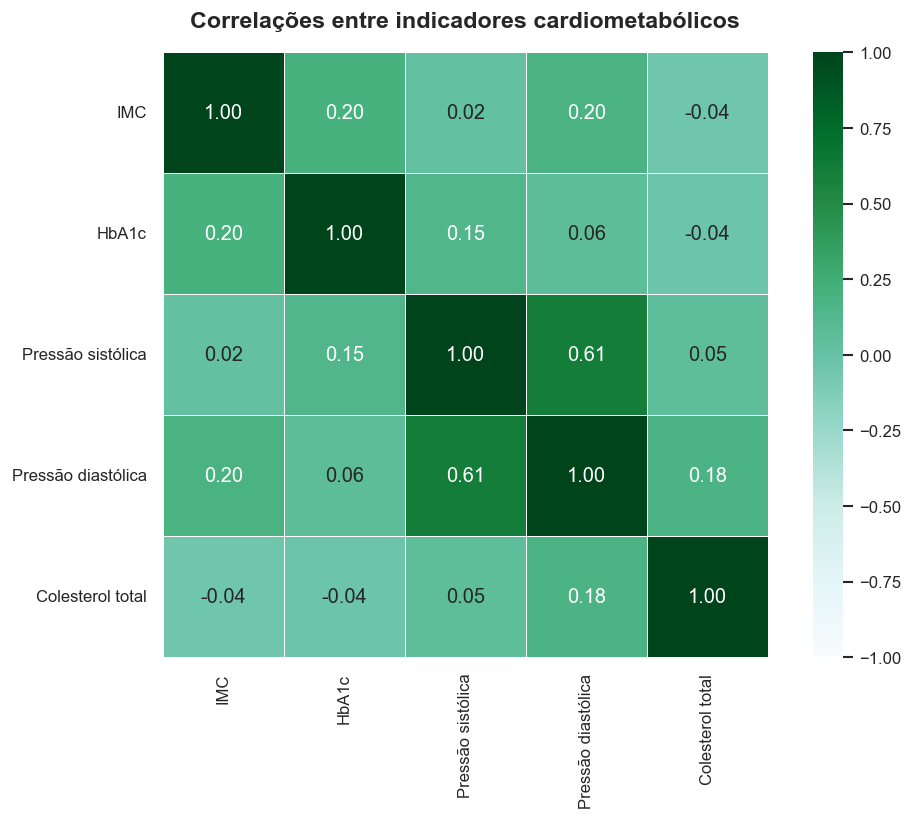

In [24]:
nomes_cardio = {
    "imc": "IMC",
    "hba1c": "HbA1c",
    "pressao_sistolica": "Pressão sistólica",
    "pressao_diastolica": "Pressão diastólica",
    "colesterol_total": "Colesterol total"
}

matriz_visual = correlacoes_cardio.rename(
    index=nomes_cardio,
    columns=nomes_cardio
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_visual,
    annot=True,
    fmt=".2f",
    cmap="BuGn",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlações entre indicadores cardiometabólicos",
    pad=15,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

O mapa de correlações permite visualizar conjuntamente as associações lineares entre os principais indicadores cardiometabólicos.

A relação mais evidente ocorre entre pressão sistólica e diastólica (**r = 0,612**), duas medidas pertencentes ao mesmo domínio e já analisadas anteriormente.

Entre indicadores de diferentes dimensões, os maiores coeficientes observados foram IMC × HbA1c (**0,197**), IMC × pressão diastólica (**0,195**) e colesterol total × pressão diastólica (**0,177**). As demais combinações apresentaram coeficientes ainda mais próximos de zero.

O conjunto dos resultados mostra que os indicadores não apresentam, em geral, associações lineares elevadas entre si. Isso sugere que diferentes variáveis podem fornecer informações complementares sobre os participantes.

Entretanto, baixa correlação linear não significa ausência de qualquer relação e também não determina a utilidade de uma variável para Machine Learning. Podem existir relações não lineares, interações entre múltiplas características ou padrões que não são representados por correlações analisadas duas a duas.

### 9.7 Síntese das relações cardiometabólicas

A análise conjunta mostrou que os principais indicadores cardiometabólicos não apresentam, em geral, correlações lineares elevadas entre si. A associação mais evidente ocorreu entre pressão sistólica e diastólica, com coeficiente de **0,612**.

Entre indicadores de diferentes dimensões, foram observadas associações positivas entre IMC e HbA1c (**0,197**), IMC e pressão diastólica (**0,195**) e colesterol total e pressão diastólica (**0,177**). As demais relações apresentaram coeficientes mais próximos de zero.

Esses resultados mostram que as variáveis analisadas representam diferentes aspectos do perfil cardiometabólico e que uma correlação linear pequena não deve ser interpretada automaticamente como ausência de informação relevante.

As associações observadas são descritivas, não estabelecem relações causais e também não representam medidas de importância das variáveis para Machine Learning.

A análise fornece, portanto, uma visão integrada dos indicadores antes da definição dos targets, da seleção das características preditoras e do treinamento dos modelos do HealthSync.